# Computing highly accurate mass transfer at rising bubbles

## Part 1 - two-phase flow simulation and data processing

In [110]:
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import torch
from os.path import join

data_file = "../datasets/ellipsoidal_bubble/log.solver"

In [111]:
with open(data_file) as f:
  cleaned_lines = [line for line in f if line.strip()[:1].isdigit()]
data = pd.read_csv(StringIO("".join(cleaned_lines)), sep=r"\s+", header=None)
data.columns = ["time", "volume", "CoM x", "CoM y", "CoM z", "CoMV x", "CoMV y", "CoMV z", "area"]
data = data[["time", "CoM x", "CoMV x"]]

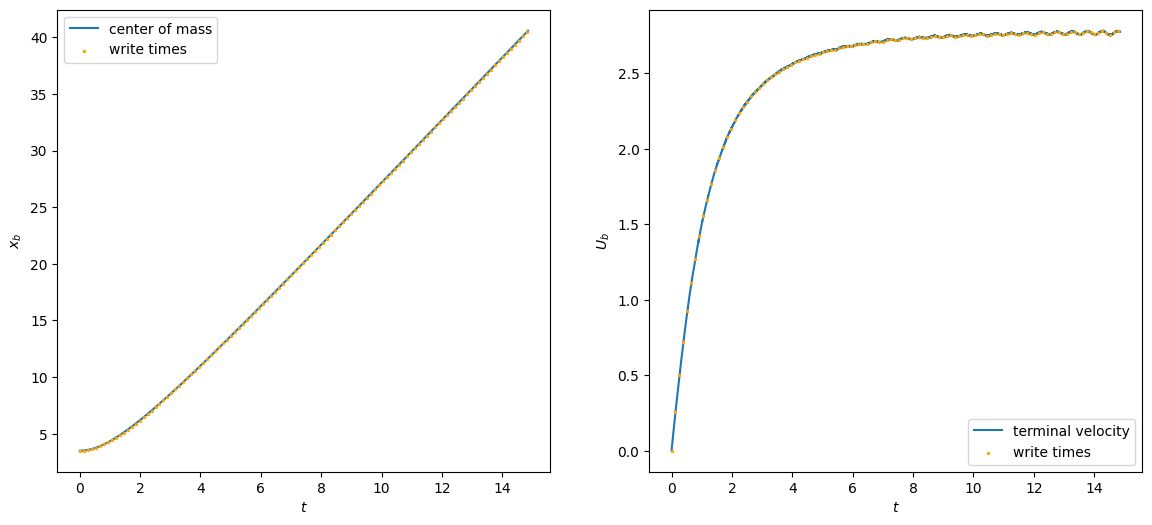

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].plot(data["time"], data["CoM x"], label="center of mass")
axes[0].scatter(data["time"][::80], data["CoM x"][::80], s=2, c="orange", label="write times", zorder=2)
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$x_b$")
axes[0].legend()

axes[1].plot(data["time"], data["CoMV x"], label="terminal velocity")
axes[1].scatter(data["time"][::80], data["CoMV x"][::80], s=2, c="orange", label="write times", zorder=2)
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel(r"$U_b$")
axes[1].legend()

plt.show()

### Interface Data

In [113]:
data_path = "../datasets/ellipsoidal_bubble/plic/"
data_file = data_path + "points_000000_n000.txt"

In [133]:
def parse_processor_file(path) -> torch.Tensor:
    lines = []
    with open(path, "r") as f:
        for line in f:
            if line.strip(): # non-empty line
                row = [float(x) for x in line.split()]
                lines.append(row)
    data = torch.tensor(lines)
    return data


#parse_processor_file(data_file)

def load_interface_snapshot(path, iteration, num_processors=4) -> torch.Tensor:
    p_data = []
    for p in range(num_processors):
        p_data.append(parse_processor_file(join(path, f"points_{iteration:06d}_n{p:03d}.txt")))
    p_data = torch.cat(p_data)
    return p_data[p_data[:, -1].abs() < 10]


load_interface_snapshot(data_path, iteration=3)

tensor([[ 3.2028,  0.0000,  0.9865, -0.0135,  0.8330,  0.0000],
        [ 3.2030,  0.0146,  0.9865, -0.0135,  0.8368, -0.0391],
        [ 3.2030,  0.0146,  0.9600, -0.0400,  0.8367, -0.0391],
        ...,
        [ 3.8672,  0.4713, -0.2854, -0.7146, -0.1040,  0.3992],
        [ 3.8672,  0.4713, -0.2951, -0.7049, -0.1040,  0.3991],
        [ 3.8733,  0.4688, -0.2951, -0.7049, -0.0903,  0.4055]])